In [1]:
import kagglehub

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


In [2]:
import os

path = r"C:\Users\PC\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2"

print(os.listdir(path))

['seg_pred', 'seg_test', 'seg_train']


In [3]:
train_path = path + "/seg_train/seg_train"
print(os.listdir(train_path))

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((150,150)),
    transforms.ToTensor()
])

train_dataset = ImageFolder(train_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print("Nombre d'images :", len(train_dataset))

Nombre d'images : 14034


In [5]:
!pip install torchvision

In [6]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 150, 150])
torch.Size([32])


In [7]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*36*36, 128),
            nn.ReLU(),
            nn.Linear(128, 6)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [8]:
images.shape

torch.Size([32, 3, 150, 150])

In [9]:
import torch

model = CNN()

images, labels = next(iter(train_loader))
outputs = model(images)

print(outputs.shape)

torch.Size([32, 6])


In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
#Optimiser + LOSS
import torch.optim as optim
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
# Training loop
epochs = 1

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")

Epoch 1, Loss: 0.9535819319902086


In [13]:
correct = 0
total = 0
 
with torch.no_grad():
    for images, labels in train_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 77.04%


In [14]:
import torch
torch.save(model.state_dict(), "daouda_model.pth")

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Générateur
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

# Modèle CNN léger
model_tf = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(6, activation='softmax')
])

model_tf.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Entraînement
model_tf.fit(train_generator, epochs=3)

# ✅ SAUVEGARDE MODERNE (.keras)
model_tf.save("daouda_model.keras")

Found 14034 images belonging to 6 classes.


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 88s 191ms/step - accuracy: 0.6439 - loss: 0.9431
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 100s 226ms/step - accuracy: 0.7902 - loss: 0.5804
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 99s 225ms/step - accuracy: 0.8606 - loss: 0.3938


In [16]:
history = model_tf.fit(train_generator, epochs=3)

print(history.history.keys())

Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 91s 207ms/step - accuracy: 0.9130 - loss: 0.2572
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 88s 200ms/step - accuracy: 0.9546 - loss: 0.1430
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.9761 - loss: 0.0889
dict_keys(['accuracy', 'loss'])


In [17]:
print("Accuracy:", history.history['accuracy'])
print("Loss:", history.history['loss'])

Accuracy: [0.9129970073699951, 0.9546102285385132, 0.9760581254959106]
Loss: [0.2571738064289093, 0.1429664045572281, 0.08886352926492691]


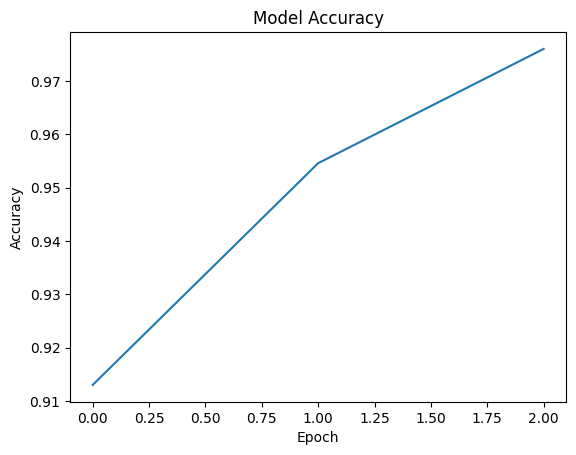

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

Le modèle montre une évolution positive de l’accuracy au cours des époques, ce qui indique un bon apprentissage.
La diminution de la loss confirme que le réseau améliore progressivement ses prédictions.

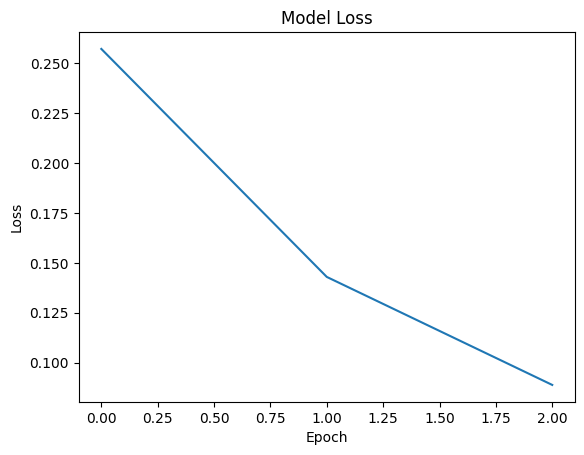

In [19]:
plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [20]:
!pip install flask

In [21]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\PC\Documents\Nouveau dossier (5)
['.git', '.gitignore', 'app.py', 'Assignme_c_vision.ipynb', 'daouda_model.keras', 'daouda_model.pth', 'model1.keras', 'model2.keras', 'README.txt', 'report.pdf', 'requirements.txt', 'runtime.txt', 'static', 'templates', 'train.py']


In [22]:
model_tf.fit(train_generator, epochs=3)

model_tf.save("daouda_model.keras")

Epoch 1/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 80s 181ms/step - accuracy: 0.9847 - loss: 0.0588
Epoch 2/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 80s 181ms/step - accuracy: 0.9864 - loss: 0.0495
Epoch 3/3
439/439 ━━━━━━━━━━━━━━━━━━━━ 79s 181ms/step - accuracy: 0.9880 - loss: 0.0517


In [23]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [24]:
history = model_tf.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.9956 - loss: 0.0237 - val_accuracy: 0.9961 - val_loss: 0.0225
Epoch 2/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 208ms/step - accuracy: 0.9956 - loss: 0.0256 - val_accuracy: 0.9330 - val_loss: 0.2106
Epoch 3/3
351/351 ━━━━━━━━━━━━━━━━━━━━ 73s 207ms/step - accuracy: 0.9865 - loss: 0.0471 - val_accuracy: 0.9879 - val_loss: 0.0364


In [25]:

model_tf.save("model1.keras")

In [29]:
model = tf.keras.models.load_model("model1.keras")

In [ ]:
# -------- MODEL 2 --------
from tensorflow.keras import layers, models
model_tf2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])

model_tf2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_tf2.fit(train_generator, epochs=5)

model_tf2.save("model2.keras")

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 191s 539ms/step - accuracy: 0.5441 - loss: 1.1925
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 186s 530ms/step - accuracy: 0.7055 - loss: 0.8052
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 184s 523ms/step - accuracy: 0.7716 - loss: 0.6477
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 197s 561ms/step - accuracy: 0.8284 - loss: 0.4890
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 213s 608ms/step - accuracy: 0.8696 - loss: 0.3622
